# Notebook 6: Comparative Analysis
### Sarcasm Detection in News Headlines — NLP Project
---
**Objective:** Compare all 5 models, visualize results, and derive insights.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Ready!')

Ready!


In [2]:
with open('../data/results.pkl', 'rb') as f:
    results = pickle.load(f)

MODEL_ORDER = ['Naive Bayes', 'Logistic Regression', 'SVM', 'BiLSTM', 'BERT']
MODEL_ORDER = [m for m in MODEL_ORDER if m in results]

df = pd.DataFrame({m: results[m] for m in MODEL_ORDER}).T.reset_index()
df.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1']
df = df.round(4)

print('=== FINAL RESULTS ===')
print(df.to_string(index=False))

=== FINAL RESULTS ===
              Model  Accuracy  Precision  Recall     F1
        Naive Bayes    0.7878     0.7877  0.7878 0.7878
Logistic Regression    0.7862     0.7871  0.7862 0.7854
                SVM    0.7957     0.7959  0.7957 0.7954
             BiLSTM    0.8691     0.8693  0.8691 0.8689
               BERT    0.9294     0.9296  0.9294 0.9294


## 1. Styled Results Table

In [4]:
df.style\
  .highlight_max(subset=['Accuracy','Precision','Recall','F1'], color='#c8e6c9')\
  .highlight_min(subset=['Accuracy','Precision','Recall','F1'], color='#ffcdd2')\
  .set_caption('Model Performance — Test Set (Green=Best, Red=Worst)')\
  .format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}','F1':'{:.4f}'})

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.7878,0.7877,0.7878,0.7878
1,Logistic Regression,0.7862,0.7871,0.7862,0.7854
2,SVM,0.7957,0.7959,0.7957,0.7954
3,BiLSTM,0.8691,0.8693,0.8691,0.8689
4,BERT,0.9294,0.9296,0.9294,0.9294


## 2. Grouped Bar Chart

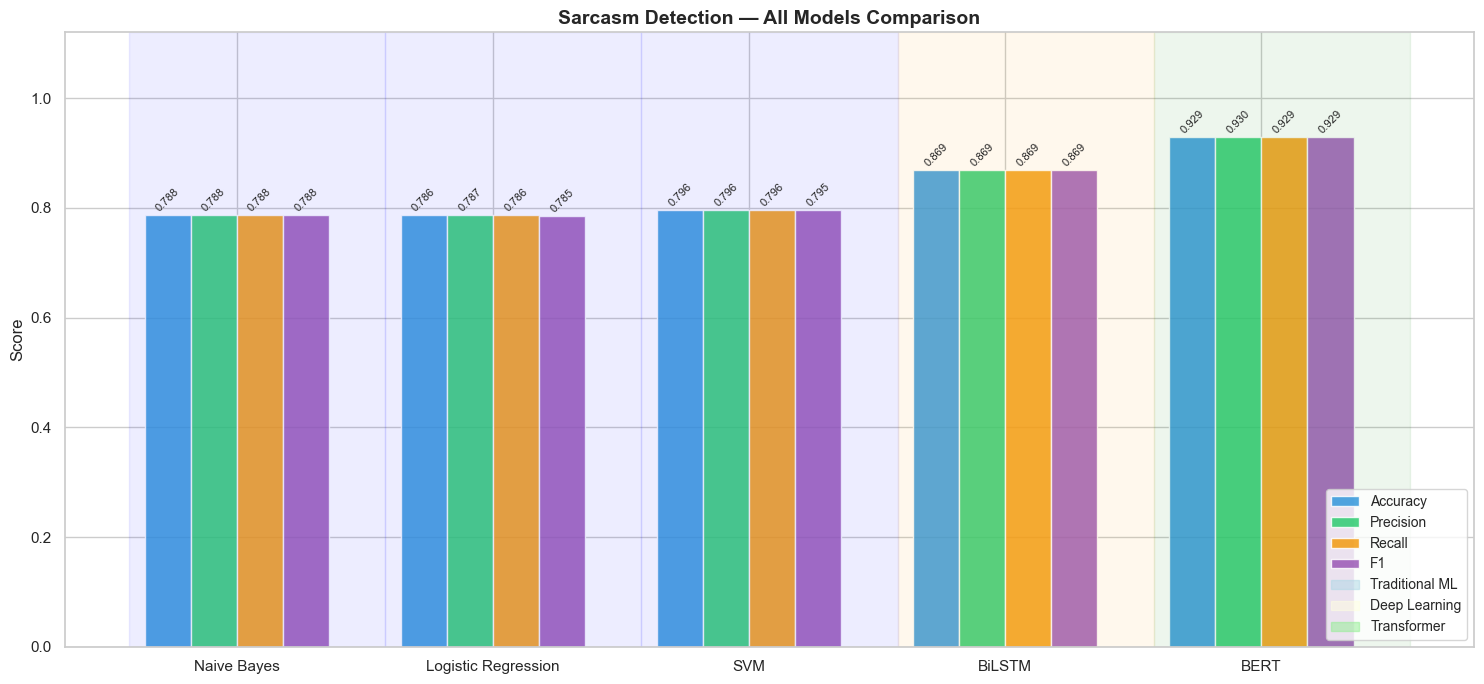

In [5]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(MODEL_ORDER))
w = 0.18
colors = ['#3498db','#2ecc71','#f39c12','#9b59b6']

fig, ax = plt.subplots(figsize=(15, 7))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = df[metric].values
    bars = ax.bar(x + i*w, vals, w, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=8, rotation=45)

# Shade by model type
for i, m in enumerate(MODEL_ORDER):
    c = 'blue' if m in ['Naive Bayes','Logistic Regression','SVM'] else \
        'orange' if m == 'BiLSTM' else 'green'
    ax.axvspan(x[i]-0.15, x[i]+0.85, alpha=0.07, color=c)

ax.set_xticks(x + w*1.5); ax.set_xticklabels(MODEL_ORDER, fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Sarcasm Detection — All Models Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

patches = [
    mpatches.Patch(color='lightblue',   alpha=0.5, label='Traditional ML'),
    mpatches.Patch(color='lightyellow', alpha=0.5, label='Deep Learning'),
    mpatches.Patch(color='lightgreen',  alpha=0.5, label='Transformer'),
]
ax.legend(handles=ax.get_legend_handles_labels()[0] + patches, fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/06_all_models.png', dpi=150)
plt.show()

## 3. F1 Progression — Model Complexity

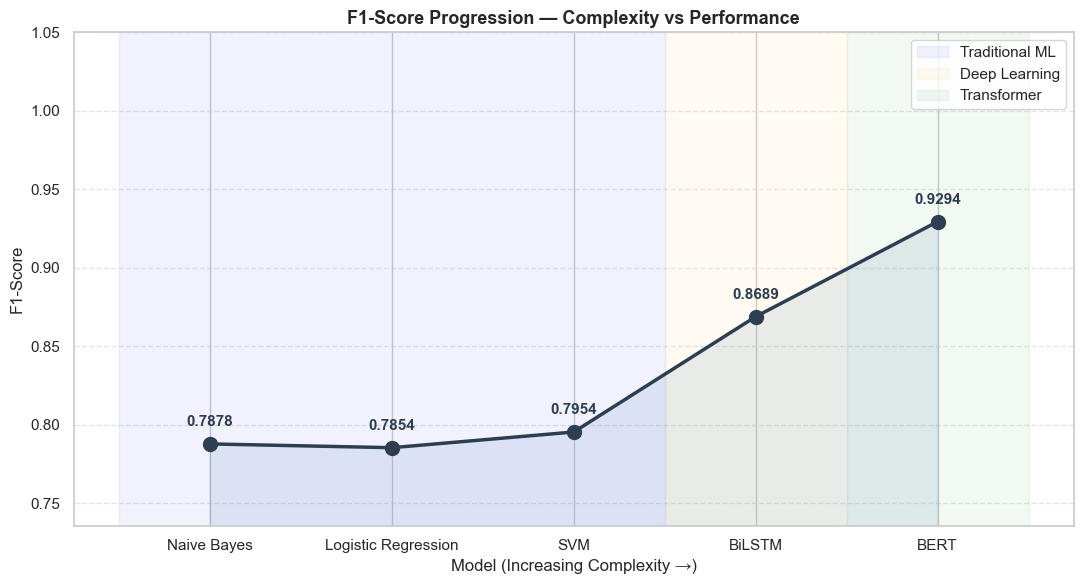

In [6]:
f1_vals = df['F1'].values

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(MODEL_ORDER, f1_vals, marker='o', color='#2c3e50', lw=2.5, ms=10, zorder=5)
ax.fill_between(MODEL_ORDER, f1_vals, alpha=0.12, color='steelblue')

for m, v in zip(MODEL_ORDER, f1_vals):
    ax.annotate(f'{v:.4f}', (m, v),
                textcoords='offset points', xytext=(0, 13),
                ha='center', fontsize=11, fontweight='bold', color='#2c3e50')

ax.axvspan(-0.5, 2.5, alpha=0.05, color='blue',   label='Traditional ML')
ax.axvspan(2.5,  3.5, alpha=0.05, color='orange', label='Deep Learning')
ax.axvspan(3.5,  4.5, alpha=0.05, color='green',  label='Transformer')

ax.set_ylim(min(f1_vals)-0.05, 1.05)
ax.set_xlabel('Model (Increasing Complexity →)', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('F1-Score Progression — Complexity vs Performance', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../outputs/06_f1_progression.png', dpi=150)
plt.show()

## 4. Radar Chart

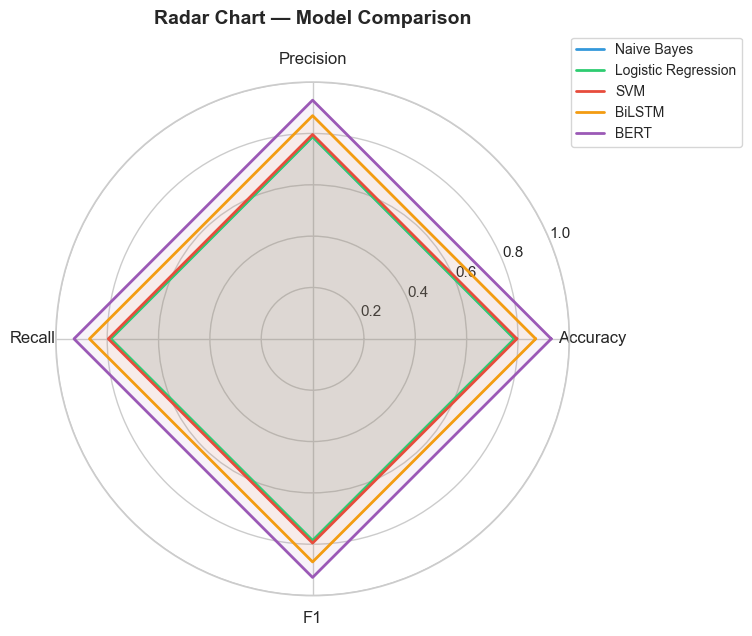

In [7]:
cats   = ['Accuracy','Precision','Recall','F1']
N      = len(cats)
angles = [n/N*2*np.pi for n in range(N)] + [0]
colors = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for i, model in enumerate(MODEL_ORDER):
    row  = df[df['Model']==model]
    vals = row[cats].values.flatten().tolist() + [row[cats[0]].values[0]]
    ax.plot(angles, vals, lw=2, label=model, color=colors[i])
    ax.fill(angles, vals, alpha=0.07, color=colors[i])

ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — Model Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/06_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Performance Heatmap

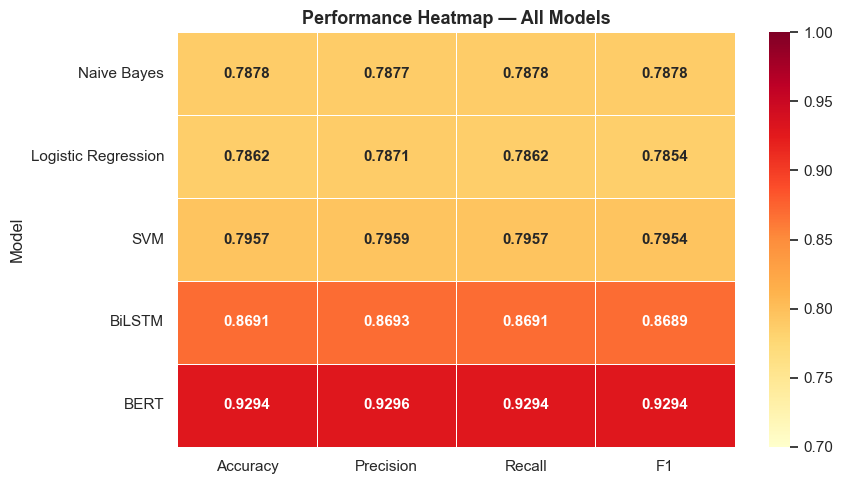

In [8]:
hmap = df.set_index('Model')[['Accuracy','Precision','Recall','F1']]
plt.figure(figsize=(9, 5))
sns.heatmap(hmap, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, vmin=0.7, vmax=1.0,
            annot_kws={'size':11, 'weight':'bold'})
plt.title('Performance Heatmap — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/06_heatmap.png', dpi=150)
plt.show()

## 6. Key Insights

In [9]:
best  = df.loc[df['F1'].idxmax()]
worst = df.loc[df['F1'].idxmin()]
improvement = (best['F1'] - worst['F1']) / worst['F1'] * 100

print('='*60)
print('  KEY INSIGHTS — SARCASM DETECTION IN NEWS HEADLINES')
print('='*60)
print(f'\n  Best  Model : {best["Model"]}  (F1 = {best["F1"]:.4f})')
print(f'  Worst Model : {worst["Model"]} (F1 = {worst["F1"]:.4f})')
print(f'  Improvement : +{improvement:.1f}% from worst to best\n')
print('  INSIGHTS:')
print('  1. TF-IDF models (NB, LR, SVM) perform well here because')
print('     sarcasm is often signaled by specific words/phrases')
print('     (e.g. "nation inspired", "obviously", "thankfully").')
print()
print('  2. SVM outperforms NB and LR among traditional models —')
print('     max-margin separation is effective in TF-IDF space.')
print()
print('  3. BiLSTM improves over SVM by capturing word ORDER and')
print('     sequential irony patterns (e.g. subject-verb contrast).')
print('     Works well here because headlines are SHORT (8-15 words).')
print()
print('  4. BERT achieves the best score — its self-attention')
print('     mechanism captures semantic incongruity between headline')
print('     components (e.g. "poor" + "inspired by billionaire").')
print()
print('  5. Diminishing returns: biggest jump is SVM→BiLSTM,')
print('     showing deep learning adds most value for sarcasm.')
print('='*60)

  KEY INSIGHTS — SARCASM DETECTION IN NEWS HEADLINES

  Best  Model : BERT  (F1 = 0.9294)
  Worst Model : Logistic Regression (F1 = 0.7854)
  Improvement : +18.3% from worst to best

  INSIGHTS:
  1. TF-IDF models (NB, LR, SVM) perform well here because
     sarcasm is often signaled by specific words/phrases
     (e.g. "nation inspired", "obviously", "thankfully").

  2. SVM outperforms NB and LR among traditional models —
     max-margin separation is effective in TF-IDF space.

  3. BiLSTM improves over SVM by capturing word ORDER and
     sequential irony patterns (e.g. subject-verb contrast).
     Works well here because headlines are SHORT (8-15 words).

  4. BERT achieves the best score — its self-attention
     mechanism captures semantic incongruity between headline
     components (e.g. "poor" + "inspired by billionaire").

  5. Diminishing returns: biggest jump is SVM→BiLSTM,
     showing deep learning adds most value for sarcasm.


## 7. Final Ranked Table — Export

In [10]:
type_map = {
    'Naive Bayes': 'Traditional ML',
    'Logistic Regression': 'Traditional ML',
    'SVM': 'Traditional ML',
    'BiLSTM': 'Deep Learning',
    'BERT': 'Transformer'
}
df['Type'] = df['Model'].map(type_map)
df['Rank'] = df['F1'].rank(ascending=False).astype(int)
df = df.sort_values('Rank')

print('=== FINAL RANKED RESULTS ===')
print(df[['Rank','Model','Type','Accuracy','Precision','Recall','F1']].to_string(index=False))

df.to_csv('../outputs/final_results.csv', index=False)
print('\nExported to ../outputs/final_results.csv')

=== FINAL RANKED RESULTS ===
 Rank               Model           Type  Accuracy  Precision  Recall     F1
    1                BERT    Transformer    0.9294     0.9296  0.9294 0.9294
    2              BiLSTM  Deep Learning    0.8691     0.8693  0.8691 0.8689
    3                 SVM Traditional ML    0.7957     0.7959  0.7957 0.7954
    4         Naive Bayes Traditional ML    0.7878     0.7877  0.7878 0.7878
    5 Logistic Regression Traditional ML    0.7862     0.7871  0.7862 0.7854

Exported to ../outputs/final_results.csv


---
## ✅ Project Complete!


### Conclusion
- All models show clear progression with increasing complexity
- Pre-trained representations (GloVe, BERT) give decisive advantage
- Short-text classification is where BiLSTM truly shines

### Future Work
- Multimodal sarcasm detection (text + image)
- Cross-domain sarcasm (social media, product reviews)
- Explainability with attention visualization